In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.style.use('ggplot')
pd.set_option('display.max_columns',200) #Expand the pandas df to show all available columns

In [6]:
from pathlib import Path

work_dir = Path().cwd().parent.joinpath('data','ml-100k','u_data.csv')

In [11]:

df = pd.read_csv(str(work_dir), header=None, names=['user_id','item_id','rating','timestamp'])

df.shape

(100000, 4)

In [12]:
df.columns #this takes the first row of the pandas df as the column header.

Index(['user_id', 'item_id', 'rating', 'timestamp'], dtype='object')

In [13]:
df.head(5)

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [14]:
df.dtypes

user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

In [ ]:
#You can drop columns from the df using the following technique
#The axis=1 denotes that we need to drop a column and not a row
#df.drop(['col1','col2'], axis=1)

#Another method
#Pick the cols you want to choose in [] and comment out the rest, for instance col2 will not be picked
#copy creates a copy, and not a reference
#df = df[['col1','#col2', 'col3']].copy()

In [24]:
#You should look into how you might want to convert between different datatypes.

#Renaming existing columns
df.columns
df = df.rename(columns={'user_id':'User_ID',
                   'item_id':'Item_ID',
                   'rating':'Rating',
                   'timestamp':'Timestamp'})

In [25]:
df.isna() #Checks for null values and tells us whether each row in the data, has a null value

,User_ID,Item_ID,Rating,Timestamp
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
99995,False,False,False,False
99996,False,False,False,False
99997,False,False,False,False
99998,False,False,False,False


In [26]:
df.isna().sum() #If any of the columns contained a null value, this would show up in the resultant sum

User_ID      0
Item_ID      0
Rating       0
Timestamp    0
dtype: int64

In [27]:
df.duplicated() #Gives us a list of duplicated values in the dataset for every row, i.e., considers individual rows to figure out duplicates

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [36]:
df.duplicated(subset=['User_ID']) #This shows the duplicated 'User_IDs'. The second occurrences will be marked as True

0        False
1        False
2        False
3        False
4        False
         ...  
99995     True
99996     True
99997     True
99998     True
99999     True
Length: 100000, dtype: bool

In [35]:
df.loc[df.duplicated(subset=['User_ID'])] #This shows the duplicated 'User_IDs'. The second occurrences will be marked as True

,User_ID,Item_ID,Rating,Timestamp
23,291,118,2,874833878
43,276,564,3,874791805
57,290,143,5,880474293
60,115,20,3,881171009
62,201,219,4,884112673
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [32]:
#Checking individual rows for duplicates:

df.query("User_ID==291")

,User_ID,Item_ID,Rating,Timestamp
18,291,1042,4,874834944
23,291,118,2,874833878
84,291,144,5,874835091
448,291,80,4,875086354
756,291,686,5,874835165
...,...,...,...,...
96563,291,562,4,874835242
97186,291,833,3,874834236
98202,291,1047,2,874834165
98524,291,508,5,874805892


In [ ]:
~df.duplicated(subset=['User_ID']) # We are swapping the True's with False's. We do this in order to get the set of non duplicates in the next cell

0         True
1         True
2         True
3         True
4         True
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [ ]:
#You can now save the non duplicated rows as a new DataFrame. The index(numbering of the rows) need to be modified though.
#This is why the reset_index() function is used. We drop the Generated Index column from the dataset.

#df.loc[~df.duplicated(subset=['User_ID'])] \
#    .reset_index(drop=True).copy()

,User_ID,Item_ID,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
67586,939,931,2,880262196
67681,936,1258,2,886833281
67961,930,121,4,879535392
68113,920,347,4,884220131


In [41]:
#Univariate Analysis

df['Item_ID'].value_counts()

Item_ID
50      583
258     509
100     508
181     507
294     485
       ... 
852       1
1505      1
1653      1
1452      1
1641      1
Name: count, Length: 1682, dtype: int64

Text(0, 0.5, 'Number of Ratings')

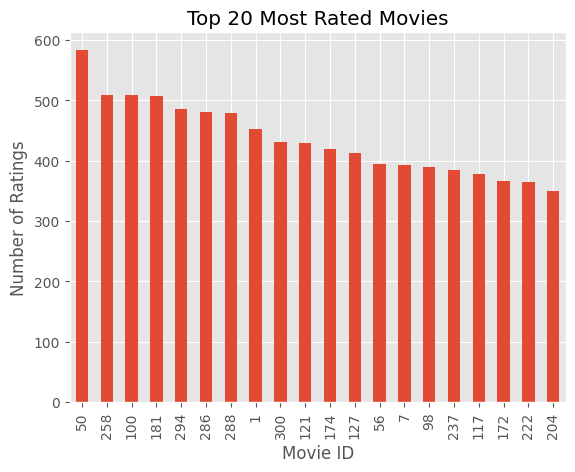

In [46]:
ax = df['Item_ID'].value_counts() \
    .head(20) \
    .plot(kind='bar', title='Top 20 Most Rated Movies') 

ax.set_xlabel('Movie ID')
ax.set_ylabel('Number of Ratings')

In [51]:
ax_kde = df['Rating'].value_counts()\
    .head(500) 
ax_kde

Rating
4    34174
3    27145
5    21201
2    11370
1     6110
Name: count, dtype: int64

Text(0, 0.5, 'Number of Items')

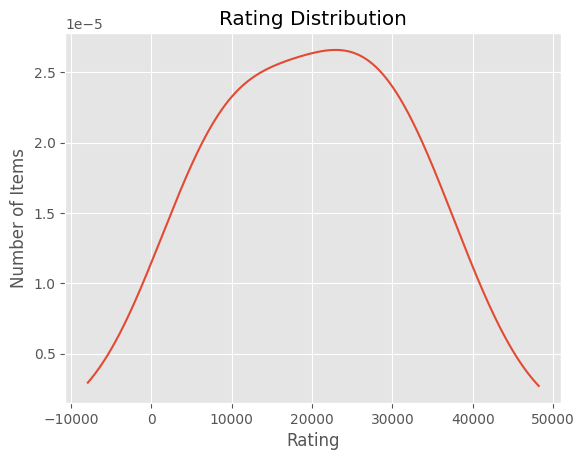

In [ ]:
ax_kde = df['Rating'].value_counts()\
    .head(500) \
    .plot(kind='kde', title='Rating Density Distribution')

ax_kde.set_xlabel('Rating')
ax_kde.set_ylabel('Number of Items')

In [ ]:
#Feature Relationships